# MAE 271: Lab 5 (OPTIONAL EXTRA CREDIT) - Roll control car simulation
### Cooper Cook & Joshua Booth

## Problem Introduction
![alt text](Lab5_schematic.png)
![alt text](Lab5_bond_grap.png)

The schematic shown above describes the roll control system of a car model that helps damp the effects of roll control. When given and applied torque on the body, the associated roll controller will produce an input that forces the body back to $\theta = 0 $. The associated bond graph above describes the system and allows us to derive state equations and state variables to produce a simulation to analyze the effectiveness of this control system in practice. The goal of this lab is to design a controller that will set the current based based upon the measurements of $ \theta ,\ \dot{\theta} ,\ \ddot{\theta}$.



## Simulation Derivation

First, state variables are selected via the bond graph assumptions made in the figures above. These are added into the state_func script that allow us to simplify the state equations seen in the next figure. 

![alt text](Lab5_state_variables.png)

Next, we derived the state equations for this system based on the bond graph modeling. Using the state variables seen above, we can derive state equations for $ \dot{P_{g}}, \dot{P_{J_{r}}}, \dot{P_{J_{m}}}, \dot{q_{L}}, \dot{q_{R}} $.

![alt text](Lab5_state_equations.png)


## Code Setup
Since we plan to do several simulations and visualize them, in this section we define several functions that allow us to simplify how this is done.

### Define Derivative Function
To solve this non-linear system of ordinary differential equations, we need to start from an initial state, numerically integrate along the state derivatives to find the next state, and repeat as desired

For integration, we will use `scipy.integrate`'s `solve_ivp()`, which takes in a range of time (`t_span`) through which to integrate, a function handle (`func`) that takes in the time and state and returns the derivatives, and the initial condition (`initial`) of the state.

Since we wish to solve this problem using several different parameters, we will define a function `get_func()` that returns a function handle that we can pass to `solve_ivp()`. We also return a function that includes additional state information.


In [1]:
from copy import deepcopy
import numpy as np


def get_func(params: dict[str, float]):
    '''
    Generate state derivative calculator functions for current simulation.
    '''
    # Make a copy of the input parameters to ensure the returned function
    # does not change when the original parameters dictionary changes
    params = deepcopy(params)

    # Get initial condition
    initial = [
        0,  # Flywheel position (theta)
        params["V_0"],  # Cylinder air volume at atmospheric pressure (q_air)
        0,  # Accumulator air volume at atmospheric pressure (q_acc)
        0,  # Flywheel momentum (p_fw)
        0,
        ]

    def func(t: float, state: list[float]):
        '''
        Calculate state derivative from current state.

        Parameters:
            t (float): Current time of simulation.
            state (list[float]): Current state of simulation.

        Returns:
            d_state (list[float]): Current state derivative.
            state_ext (dict[str, float]): Extended state information.
        '''
        # Create current extended state dict
        s: dict[str, float] = params.copy()
        s["t"] = t
        
        # Make a copy of state variables in case they get changed
        state = deepcopy(state)
        s["p_g"] = state[0]
        s["p_J_m"] = state[1]
        s["p_J_r"] = state[2]
        s["q_L"] = state[3]
        s["q_R"] = state[4]

        s["i_c"] = s["K_a"] * s["p_J_r"] / s["J_r"]     # Controller current (A)

        s["C_L"] = (s["V_0"] + s["q_L"]) / (s["rho"] * s["c"]**2)    # Left accumulator compliance (m^4*s/kg)
        s["C_R"] = (s["V_0"] + s["q_L"]) / (s["rho"] * s["c"]**2)    # Right accumulator compliance (m^4*s/kg)
        
        v_L = s["p_g"] / s["m"] - s["p_J_r"] * s["a"] / s["J_r"]
        v_R = s["p_g"] / s["m"] + s["p_J_r"] * s["a"] / s["J_r"]
        e_v_L = s["q_L"] * s["C_L"] - s["b_d"] * v_L
        e_v_R = s["q_R"] * s["C_R"] - s["b_d"] * v_R
        s["f_c"] = s["i_c"] * s["R_w"] + s["T_m"] * s["p_J_m"] / s["J_m"]
        s["P_c"] = s["i_c"] * s["f_c"]  # Controller power

        #----- Flywheel/piston kinematics --------------------
        s["d_p_g"] = - s["m"] * s["g"] + e_v_L + e_v_R
        s["d_p_J_m"] = s["q_L"] * s["C_L"] / (s["A"] * s["g_a"]) - s["q_R"] * s["C_R"] / (s["A"] * s["g_a"]) + s["T_m"] * s["i_c"]
        s["d_p_J_r"] = s["tau_i"] + e_v_L / s["a"] + e_v_R / s["a"]
        s["d_q_L"] = - v_L - s["p_J_m"] * s["A"] * s["g_a"] / s["J_m"]
        s["d_q_R"] = - v_R - s["p_J_m"] * s["A"] * s["g_a"] / s["J_m"]


        #----- Concatenate state derivatives -----------------
        d_state: list[float] = [
            s["d_p_g"],
            s["d_p_J_m"],
            s["d_p_J_r"],
            s["d_q_L"],
            s["d_q_R"], # Don't worry, this is a float, not an NDArray
            ]
        return d_state, s

    def func_wrap(t: float, state: list[float]):
        """
        Since solve_ivp() needs a function that only returns the state
        derivatives, we create a wrapper for func() that discards the rest of
        the state and returns only the state derivatives
        """
        d_state, _ = func(t, state)
        return d_state

    return func, func_wrap, initial


### Propagate Solution Using `solve_ivp()`
Now that we have a function that calculates the state derivatives given the state, we need to propagate the solution throughout time. The function `solve_problem()` was designed to use the `get_func()` function we defined earlier, calculate the solution using `scipy.integrate`'s `solve_ivp()`, and consolidate the interesting parts of the solution and the parameters given to define it. This is unchanged from the previous lab assignment.

In [2]:
from state_func import get_func
from scipy.integrate import solve_ivp
import pandas as pd
import numpy as np


def solve_problem(
        params: dict[str, float],
        t_eval: np.ndarray,
        name: str,
        rtol: float = 1e-12,
        atol: float = 1e-12,
    ):

    func, func_wrap, initial = get_func(params)
    output = solve_ivp(
        func_wrap,
        (min(t_eval), max(t_eval)),
        initial,
        t_eval=t_eval,
        method="RK45",
        rtol=rtol,
        atol=atol,
    )

    ts = output.t
    ys = output.y

    states: list[dict[str, float]] = []
    for t, y in zip(ts, ys.T):
        d_state, state = func(t, y)
        states.append(state)

    df = pd.DataFrame(states)

    solution = {
        "params": params.copy(),
        "data": df,
        "name": name,
    }

    return solution


### Define Plotting Functions
To visualize the solutions, we can create plots that describe the behavior of the flywheel and piston crank arm with the added controller to regulate the flyhweel angular velocity. Since we have several solutions we would like to plot together, we create functions to consolidate the code. `plot_2d()` takes in a list of dictionaries outputted from `solve_problem()`.

In [3]:
from matplotlib.axes import Axes
from matplotlib.colors import hsv_to_rgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def plot_2d(
    solutions: list[dict[str, str | pd.DataFrame]], 
    plot_keys: list[tuple[str, str]], 
    title: str
    ):
    '''
    Generate a plot for all pairs of plot_keys using the given solutions.
    This function intelligently shares axes when possible and generates new
    axes when necessary.

    Parameters:
        solutions (list[dict[str, str | pandas.DataFrame]]): The list of solutions
            to plot where in each solution is a dict with keys "name" and "data",
            where "name" is a string describing the particular solution and "data"
            is a pandas DataFrame object.
        plot_keys (list[tuple[str, str]]): A list of key-pairs to plot. Each key in
            the key-pairs must be keys in the solution["data"] DataFrame.
        title (str): Title of the plot.

    Returns:
        fig (matplotlib Figure): The Figure object associated with this plot.
    '''

    fig = plt.figure()

    # Declare colors for each pair of plot_keys. The color will fade with different solutions
    hue = np.linspace(0, 1, len(plot_keys), endpoint=False)
    sat = np.linspace(1, 0.1, len(solutions))
    val = 0.8

    # ---- Generate axes for each key pair ----
    axes: dict[tuple[str, str], Axes] = {}  # Keys and their associated axis
    x_keys: dict[str, list[Axes]] = {}
    y_keys: dict[str, list[Axes]] = {}
    keys_dict: dict[str, list[float]] = {}  # Consolidated data
    for i, keys in enumerate(plot_keys):
        assert keys not in axes.keys(), f"Redundant plotting keys '{keys}'. Each plotting key tuple should be unique."
        if keys[0] in x_keys.keys():
            # If x-key has been seen before, make a copy of the Axes associated with it
            seen_ax = x_keys[keys[0]][0]
            axes[keys] = seen_ax.twinx()
            x_keys[keys[0]].append(axes[keys])
            
            # Add corresponding y-key to dict
            if keys[1] in y_keys.keys():
                y_keys[keys[1]].append(axes[keys])
            else:
                y_keys[keys[1]] = [axes[keys]]
        else:
            if keys[1] in y_keys.keys():
                # If y-key has been seen before, make a copy of the Axes associated with it
                seen_ax = y_keys[keys[1]][0]
                axes[keys] = seen_ax.twiny()
                y_keys[keys[1]].append(axes[keys])
                
                # Add corresponding x-key to dict
                if keys[0] in x_keys.keys():
                    x_keys[keys[0]].append(axes[keys])
                else:
                    x_keys[keys[0]] = [axes[keys]]
            elif i > 0:
                phantom_x_axis = axes[plot_keys[0]].twinx()
                axes[keys] = phantom_x_axis.twiny()
                x_keys[keys[0]] = [axes[keys]]
                y_keys[keys[1]] = [phantom_x_axis]
            else: 
                # If neither key in key-pair have been seen before, 
                # make a new plot and create new entries for the keys
                axes[keys] = fig.add_subplot()
                x_keys[keys[0]] = [axes[keys]]
                y_keys[keys[1]] = [axes[keys]]


    assert len(x_keys.keys()) <= 2, f"Too many x-axes for 2D plot: {x_keys}. Maximum is 2."
    assert len(y_keys.keys()) <= 2, f"Too many y-axes for 2D plot: {y_keys}. Maximum is 2."

    for j, solution in enumerate(solutions):
        name = solution["name"]
        df: pd.DataFrame = solution["data"]

        # Collect data for all referenced keys in solution
        for key in (x_keys.keys() | y_keys.keys()):
            keys_dict[key] = df.get(key).to_numpy()

        for i, keys in enumerate(plot_keys):
            axes[keys].plot(
                keys_dict[keys[0]], keys_dict[keys[1]], 
                label=f"{keys[0]} vs. {keys[1]}: {name}", 
                c=hsv_to_rgb([hue[i], sat[j], val])
                )
    
    # Add axis labels for each key on each axis
    for i, key in enumerate(x_keys):
        x_keys[key][0].set_xlabel(f"{key}")
        if i > 0: 
            x_keys[key][0].xaxis.tick_top()
            x_keys[key][0].xaxis.set_label_position("top")
    for i, key in enumerate(y_keys):
        y_keys[key][0].set_ylabel(f"{key}")
        if i > 0: 
            y_keys[key][0].yaxis.tick_right()
            y_keys[key][0].yaxis.set_label_position("right")

    # Set plot title using a single axis
    axes[plot_keys[0]].set_title(title, y=1.12)
    fig.legend() # Add legend
    fig.tight_layout()
    return fig


## Simulation
To evaluate the controller effects on the roll control system, we attempted to produce plots of the roll system with given torque inputs and supplied gains of the controller. We were not fully able to produe the plots hoping to achieve due to time contraints of finishing the lab. 

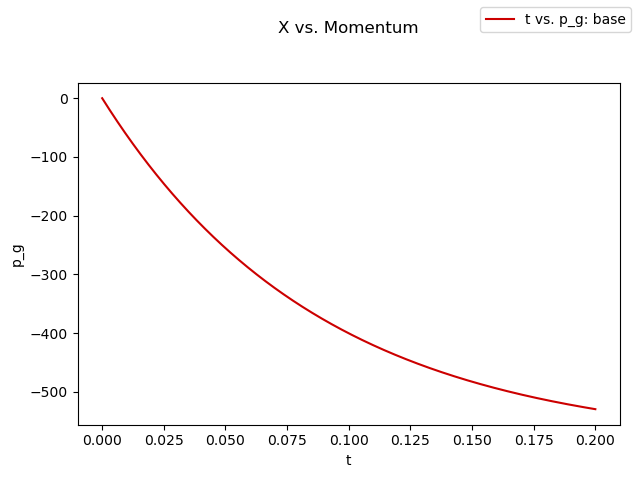

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from solve_problem import solve_problem
from plot import plot_2d, plot_ani
plt.rcParams["animation.html"] = "jshtml"

# -----------------------------
# Initial Global Parameters
# -----------------------------
params: dict[str, float] = {}
 
# Flywheel and piston rod
params["a"] = 3 * 12 / 0.0254   # a (ft -> m)
params["m"] = 1500 / 2.2 # weight (lbs -> kg)
params["g"] = 9.81        # Gravitational acceleration (m/s^2)
params["J_r"] = params["m"]*(2*params["a"])**2   # J_r
params["D"] = 2.5 * 0.0254    # Piston diameters (in -> m)
params["A"] = np.pi * params["D"] / 4   # Piston area (m^2)
params["g_p"] = 1 * 0.0254  # Ball screw pitch (in -> m)
params["g_a"] = params["g_p"] / (2 * np.pi)   # Ball screw gain (m / rad)
params["tau_i"] = 5000   # Input torque (Nm)
params["rho"] = 1.225 # Air density (kg/m^3)
params["c"] = 340 # Speed of sound (m/s^2)

params["K_a"] = 100000    # Controller proportional gain
params["R_w"] = 1    # Winding resistance (Ohm)
params["R_m"] = 2 * 0.0254    # Radius (in -> m)
params["m_m"] = 5 / 2.2  # Rotor mass (lbs -> kg)
params["J_m"] = params["m_m"] * params["R_m"]**2 / 2    # Rotary inertia
params["T_m"] = 0.54  # Motor constant (Nm/A)
params["damping_ratio"] = 0.3   # Passive damping ratio
params["f_n"] = 1.5 # Natural frequency (Hz)
params["b_d"] = 2 * params["damping_ratio"] * params["f_n"] * 2*np.pi * params["m"]    # Damping coefficient

params["h"] = 20 * 0.0254 # Cylinder height (in -> m)
params["V_0"] = params["A"] * params["h"] # Cylinder volume (m^3)

# Time
t_start: float = 0
t_end: float = 0.2
t_increment: float = 0.0001

t_span = (t_start, t_end)
t_eval = np.arange(min(t_span), max(t_span)+t_increment, t_increment)


# Run simulations
solutions: list[str, dict[str, float]] = []
solutions.append(solve_problem(params, t_eval, f"base"))

# ani = plot_ani(solutions)
fig1 = plot_2d(solutions, [("t", "p_g")], "X vs. Momentum")
# plt.axis('equal')

# fig = plot_time(solutions)

# from IPython.display import HTML
# HTML(ani.to_jshtml())

plt.show()

## Conclusions
As seen above, we started the derivations of the associated state variables and state equations for the roll control system presented in the lab. The state equations and inputs were put into the code functions in an attempt to produce plots for the roll control simulation. Due to time constraints, the plots we wanted to show were not achieved, but the attempt was there. 
